In this notebook, we try to solve the one norm problem with cost function 

\begin{equation}
    J(u) = \|Au - b\|_2^2 + \alpha \|u\|_1
\end{equation}

by rewriting it into a least squares problem and using CIL build in functions to minimize 
the least squares problem. In each iteration, the least squares problem is

\begin{equation*}
    u_{k+1} = \arg\min_u \left\| \begin{bmatrix}
        A\\
        \lambda W^{(k)}
    \end{bmatrix}u - \begin{bmatrix}
        b\\
        0
    \end{bmatrix}\right\|_2^2
\end{equation*}

with $W^{(k)} = \text{diag}\{u^{(k)^{-1/2}}\}$

In [43]:
# import necessary packages

# CIL imports
from cil.framework import ImageGeometry, AcquisitionGeometry, BlockDataContainer, ImageData

# From cil.plugins import TomoPhantom
from phantominator import shepp_logan

from cil.optimisation.functions import LeastSquares

# For display
from cil.utilities.display import show2D, show1D, show_geometry

# ASTRA imports
from cil.plugins.astra.operators import ProjectionOperator

from cil.optimisation.algorithms import CGLS, GD

# External imports
import numpy as np
import matplotlib.pyplot as plt
import logging

from cil.optimisation.operators import BlockOperator, DiagonalOperator

In [44]:
# setting pixels and angles
n_pixels = 50
n_angles = 40

## Setting up the phantom, sinogram, imagedata, etc.

In [45]:
# Set logging level for CIL processors:
logging.basicConfig(level=logging.WARNING)
cil_log_level = logging.getLogger('cil.processors')
cil_log_level.setLevel(logging.INFO)

# Setting background defaults
cmap = "rainbow"
device = "cpu"

In [46]:
# Angles
angles = np.linspace(0, 180, n_angles, endpoint=False, dtype=np.float32)

# Setup acquisition geometry
ag = AcquisitionGeometry.create_Parallel2D()\
                            .set_angles(angles)\
                            .set_panel(n_pixels, pixel_size=1/n_pixels)

# Setup image geometry
ig = ImageGeometry(voxel_num_x=n_pixels, 
                   voxel_num_y=n_pixels, 
                   voxel_size_x=1/n_pixels, 
                   voxel_size_y=1/n_pixels)

# Get phantom
phantom = ImageData(np.flip(shepp_logan(n_pixels)), geometry = ig)

# Create projection operator using Astra-Toolbox.
A = ProjectionOperator(ig, ag, device)

# Create an acquisition data (numerically)
sino = A.direct(phantom)

c:\Users\femke\anaconda3\envs\cil_demos_cpu\Lib\site-packages\cil\framework\data_container.py:112: UserWarning: Over-riding geometry.dtype with data.dtype
  warnings.warn("Over-riding geometry.dtype with data.dtype", UserWarning)


## Creating block algorithm

In underneath function, cgls is used to minimize the least squares problem

In [ ]:
def onenorm_cgls(initial, max_inner_iter, max_outer, A, sino, alpha):
    uk = initial.copy()

    for k in range(max_outer):

        print("test if uk changes", uk.as_array()[4,4])
        
        # reweight the data fidelity term

        # IMPORTANT, I THINK IT SHOULD BE **(-1/2), but it leads to nan for negative uk values,
        # need to do something else than abs, because abs does not work with image data
        w_imagedata = (uk + 1e-8) ** (-1) # add very small number to avoid division by zero
        w_operator = DiagonalOperator(w_imagedata)

        # create block operator
        operator_block = BlockOperator(A, alpha*w_operator)

        # create block data container
        zero_block = w_operator.range.allocate(0)
        data_block = BlockDataContainer(sino, zero_block)

        # solver inner minimization problem 
        cgls = CGLS(initial=uk, operator=operator_block, data=data_block, update_objective_interval=10)

        cgls.run(max_inner_iter, verbose=None)
        uk = cgls.solution

    return uk

In the code below, we run the function above. Intererstingly enough, it works best for very very small alpha. It runs for $\alpha \leq 1e-8$. It seems to be unstable for large values of $\alpha$.

In [97]:
x0 = ig.allocate(0)
test_no_reg = onenorm_cgls(x0, 100, 10, A, sino, 0) 

test if uk changes 0.0


  0%|          | 0/100 [00:00<?, ?it/s]

test if uk changes -0.038030446


  0%|          | 0/100 [00:00<?, ?it/s]

test if uk changes -0.034025013


...

  0%|          | 0/100 [00:00<?, ?it/s]

test if uk changes -0.05369296


  0%|          | 0/100 [00:00<?, ?it/s]

test if uk changes -0.05405181


  0%|          | 0/100 [00:00<?, ?it/s]

test if uk changes 0.0


  0%|          | 0/100 [00:00<?, ?it/s]

test if uk changes 8.531615e-06


  0%|          | 0/100 [00:00<?, ?it/s]

test if uk changes 1.8204641e-11


...

  0%|          | 0/100 [00:00<?, ?it/s]

test if uk changes -3.8227537e-08


  0%|          | 0/100 [00:00<?, ?it/s]

test if uk changes -3.8227537e-08


  0%|          | 0/100 [00:00<?, ?it/s]

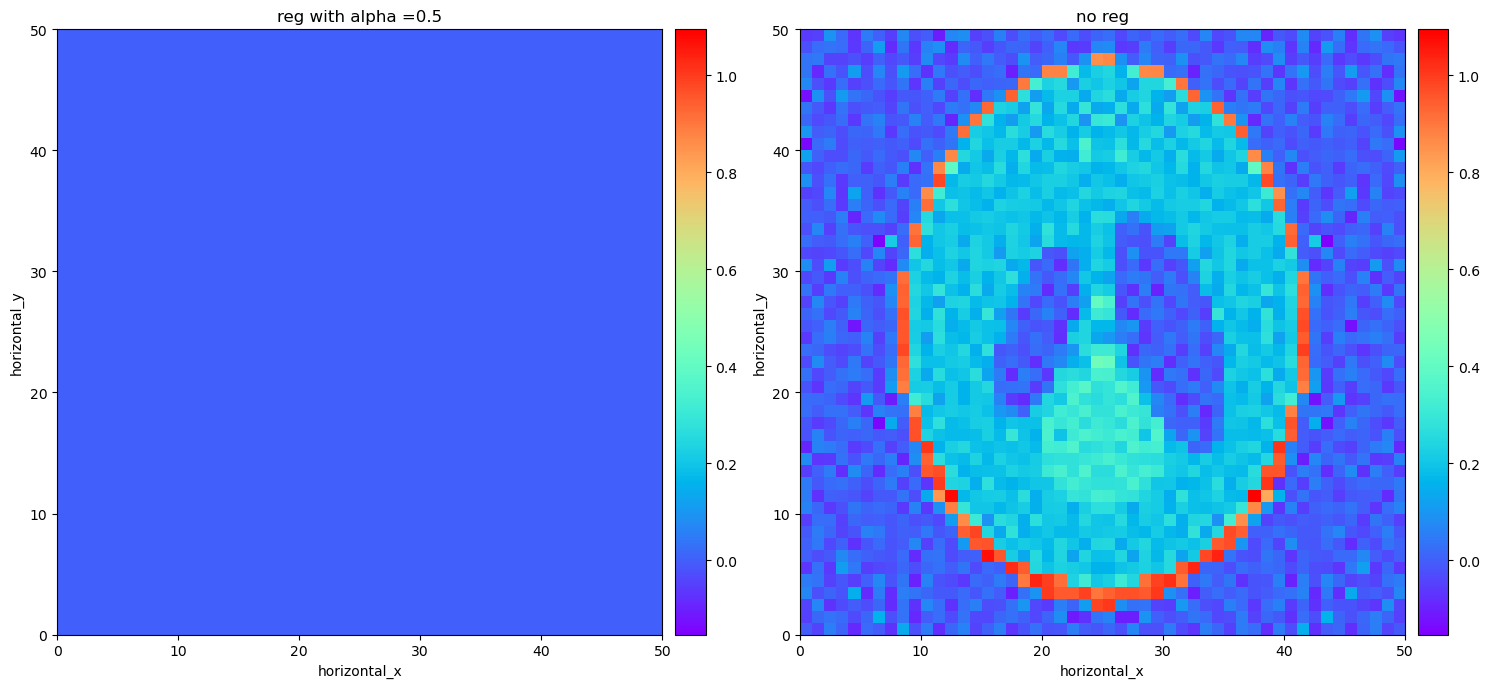

In [100]:
alpha = 0.5
test_reg = onenorm_cgls(x0, 100, 10, A, sino, alpha) 

show2D([test_reg, test_no_reg], [f'reg with alpha ={alpha}', 'no reg'], cmap=cmap, fix_range=True)

In [53]:
def onenorm_gd(initial, max_inner_iter, max_outer, A, sino, alpha):
    uk = initial.copy()

    for k in range(max_outer):

        print("test if uk changes", uk.as_array()[4,4])
        
        # reweight the data fidelity term
        w_imagedata = (uk + 1e-8) ** (-1/2) # add very small number to avoid division by zero
        w_operator = DiagonalOperator(w_imagedata)

        # create block operator
        operator_block = BlockOperator(A, alpha*w_operator)

        # create block data container
        zero_block = w_operator.range.allocate(0)
        data_block = BlockDataContainer(sino, zero_block)

        # solver inner minimization problem 
        fmin = LeastSquares(operator_block, data_block)
        GD_fmin = GD(initial=x0, f=fmin, step_size=0.1, update_objective_interval=10)

        GD_fmin.run(max_inner_iter, verbose=1)
        uk = GD_fmin.solution

    return uk

In [54]:
test2 = onenorm_gd(x0, max_inner_iter=100, max_outer=5, A=A, sino=sino, alpha=0.1)

test if uk changes 0.0


  0%|          | 0/100 [00:00<?, ?it/s]

c:\Users\femke\anaconda3\envs\cil_demos_cpu\Lib\site-packages\cil\framework\data_container.py:516: RuntimeWarning: overflow encountered in multiply
  pwop(self.as_array(), x2.as_array(), *args, **kwargs )


test if uk changes nan


  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

test if uk changes nan


  0%|          | 0/100 [00:00<?, ?it/s]

test if uk changes nan


  0%|          | 0/100 [00:00<?, ?it/s]